# Implement Polynomial Regression Model
Polynomial Regression is used when the relationship between X and Y is not linear.

| Linear           | Polynomial                 |
| ---------------- | -------------------------- |
| Straight line    | Curve                      |
| One feature term | Multiple powers of feature |
| Simpler          | More flexible              |
| Less overfitting | Higher overfitting risk    |


Is Polynomial Regression a Linear Model or Non-Linear Model?

Tricky Answer:

Polynomial Regression models a non-linear relationship, but the model itself is linear in the coefficients.

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Position_Salaries.csv')
print(dataset)
print(dataset.shape)

            Position  Level   Salary
0   Business Analyst      1    45000
1  Junior Consultant      2    50000
2  Senior Consultant      3    60000
3            Manager      4    80000
4    Country Manager      5   110000
5     Region Manager      6   150000
6            Partner      7   200000
7     Senior Partner      8   300000
8            C-level      9   500000
9                CEO     10  1000000
(10, 3)


In [45]:
x = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values

In [46]:
print(x)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]


In [38]:
print(y)

[  45000   50000   60000   80000  110000  150000  200000  300000  500000
 1000000]


In [39]:
print(dataset.isnull().sum())

Position    0
Level       0
Salary      0
dtype: int64


In [40]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [41]:
print(x_train)
print(x_test)
print(y_train)
print(y_test)

[[ 5]
 [10]
 [ 2]
 [ 7]
 [ 8]
 [ 4]
 [ 1]
 [ 6]]
[[3]
 [9]]
[ 110000 1000000   50000  200000  300000   80000   45000  150000]
[ 60000 500000]


**Training the Linear Regression Model on Training Data set**

In [48]:
from sklearn.linear_model import LinearRegression
linear_regressor = LinearRegression()
linear_regressor.fit(x, y)

LinearRegression()

**Training the Polynomial Linear Regression Model on Training Data set**

In [63]:
from sklearn.preprocessing import PolynomialFeatures
poly_regressor = PolynomialFeatures(degree=2) # create polynomial object
x_poly = poly_regressor.fit_transform(x)  # create matrix of powered features
linear_regressor_2 = LinearRegression() # create linear regressor object/instance
linear_regressor_2.fit(x_poly, y) # Train Linear Regression on transformed polynomial features.

LinearRegression()

**Visualizing the Linear Regression Model Results**

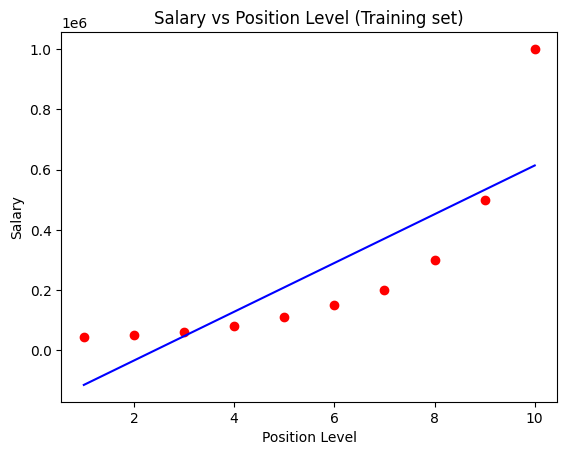

In [61]:
plt.scatter(x, y, color='red')
plt.plot(x, linear_regressor.predict(x), color='blue')
plt.title('Salary vs Position Level (Training set)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()

**Visualizing the Polynomial Regression Model Results**

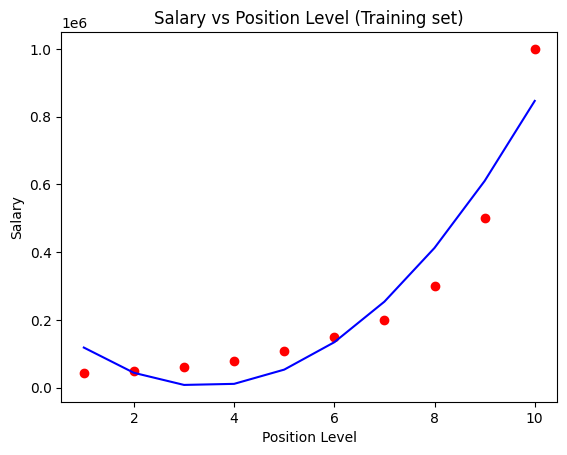

In [64]:
plt.scatter(x, y, color='red')
plt.plot(x, linear_regressor_2.predict(x_poly), color='blue')
plt.title('Salary vs Position Level (Training set)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()

**Visualizing** the polynomial regression results (for higher resolution and smoother curve)

In [65]:
from sklearn.preprocessing import PolynomialFeatures
poly_regressor = PolynomialFeatures(degree=3) # create polynomial object
x_poly = poly_regressor.fit_transform(x)  # create matrix of powered features
linear_regressor_3 = LinearRegression() # create linear regressor object/instance
linear_regressor_3.fit(x_poly, y) # Train Linear Regression on transformed polynomial features.

LinearRegression()

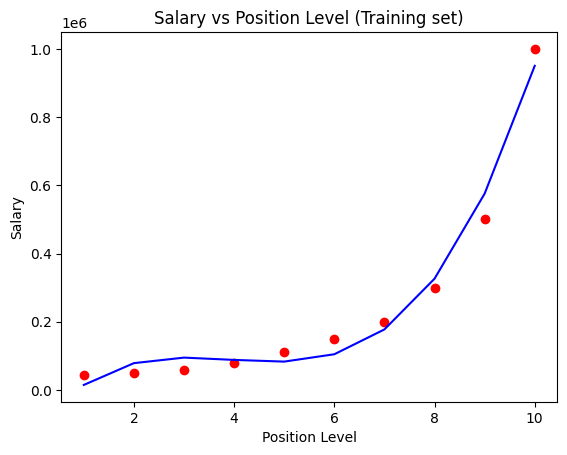

In [66]:
plt.scatter(x, y, color='red')
plt.plot(x, linear_regressor_3.predict(x_poly), color='blue')
plt.title('Salary vs Position Level (Training set)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()

In [73]:
from sklearn.preprocessing import PolynomialFeatures
poly_regressor = PolynomialFeatures(degree=4) # create polynomial object
x_poly = poly_regressor.fit_transform(x)  # create matrix of powered features
linear_regressor_4 = LinearRegression() # create linear regressor object/instance
linear_regressor_4.fit(x_poly, y) # Train Linear Regression on transformed polynomial features.

LinearRegression()

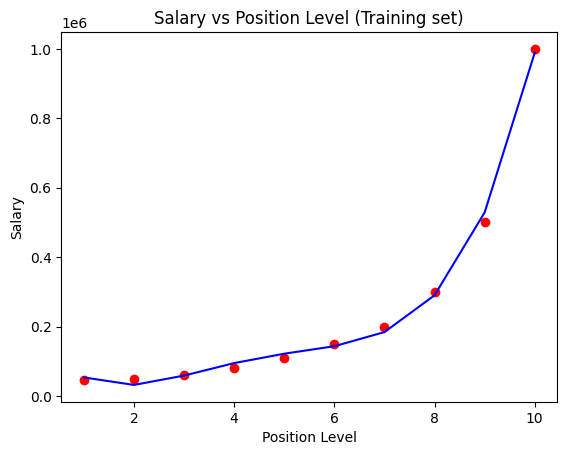

In [74]:
plt.scatter(x, y, color='red')
plt.plot(x, linear_regressor_4.predict(x_poly), color='blue')
plt.title('Salary vs Position Level (Training set)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()

**Predicting New Results with Linear Regression**

In [78]:
linear_regressor.predict([[6.5]])


array([330378.78787879])

**Predicting New Results with Polynomial Regression**

In [79]:
linear_regressor_4.predict(poly_regressor.fit_transform([[6.5]]))

array([158862.45265155])